## Phần 3: Biến đổi hình học (Geometric Transformations)


### 1. Tải ảnh mẫu thực nghiệm tự động

In [ ]:
import os
import urllib.request

os.makedirs('images', exist_ok=True)
urls = {
    'images/lena.jpg': 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg',
    'images/sudoku.png': 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/sudoku.png'
}

for path, url in urls.items():
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)


### 2. Khai báo thư viện

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


### 3. Tự cài đặt các hàm giải ma trận biến đổi & Warping (From Scratch)

In [ ]:
def compute_affine_matrix(pts_src, pts_dst):
    """Giải hệ phương trình tuyến tính A*m = b từ 3 cặp điểm để tìm ma trận Affine 2x3 (6 DoF)"""
    A, b = [], []
    for (x, y), (xp, yp) in zip(pts_src, pts_dst):
        A.append([x, y, 1, 0, 0, 0])
        A.append([0, 0, 0, x, y, 1])
        b.extend([xp, yp])
    m = np.linalg.solve(np.array(A, dtype=np.float64), np.array(b, dtype=np.float64))
    return m.reshape((2, 3))


def compute_homography_dlt(pts_src, pts_dst):
    """Thuật toán Direct Linear Transformation (DLT) dùng SVD từ 4 cặp điểm để tìm Homography 3x3 (8 DoF)"""
    A = []
    for (x, y), (xp, yp) in zip(pts_src, pts_dst):
        A.append([-x, -y, -1, 0, 0, 0, xp * x, xp * y, xp])
        A.append([0, 0, 0, -x, -y, -1, yp * x, yp * y, yp])
    # Phân tích suy biến SVD: nghiệm là vector riêng ứng với singular value nhỏ nhất
    _, _, Vt = np.linalg.svd(np.array(A, dtype=np.float64))
    H = Vt[-1].reshape((3, 3))
    return H / H[2, 2] # Chuẩn hóa h33 = 1


def warp_scratch(img, M, out_shape):
    """Biến đổi hình học bằng Backward Mapping (Inverse Warping) + Nội suy Bilinear Interpolation"""
    out_h, out_w = out_shape
    in_h, in_w = img.shape[:2]

    # Mở rộng ma trận lên 3x3 nếu là ma trận Affine (2x3)
    if M.shape == (2, 3):
        H = np.vstack([M, [0, 0, 1]])
    else:
        H = M.copy()

    H_inv = np.linalg.inv(H)

    # Tạo lưới tọa độ điểm ảnh đích
    y_idx, x_idx = np.indices((out_h, out_w))
    dst_coords = np.stack([x_idx.ravel(), y_idx.ravel(), np.ones(out_h * out_w)], axis=0)

    # Ánh xạ ngược: src = H^-1 * dst
    src_coords = H_inv @ dst_coords
    src_x = src_coords[0] / src_coords[2]
    src_y = src_coords[1] / src_coords[2]

    # Tọa độ 4 điểm nguyên lân cận để nội suy song tuyến tính
    x0 = np.floor(src_x).astype(np.int32)
    x1 = x0 + 1
    y0 = np.floor(src_y).astype(np.int32)
    y1 = y0 + 1

    valid = (x0 >= 0) & (x1 < in_w) & (y0 >= 0) & (y1 < in_h)

    wa = (x1 - src_x) * (y1 - src_y)
    wb = (x1 - src_x) * (src_y - y0)
    wc = (src_x - x0) * (y1 - src_y)
    wd = (src_x - x0) * (src_y - y0)

    x0_c = np.clip(x0, 0, in_w - 1)
    x1_c = np.clip(x1, 0, in_w - 1)
    y0_c = np.clip(y0, 0, in_h - 1)
    y1_c = np.clip(y1, 0, in_h - 1)

    Ia, Ib = img[y0_c, x0_c], img[y1_c, x0_c]
    Ic, Id = img[y0_c, x1_c], img[y1_c, x1_c]

    interp = (wa[:, None] * Ia + wb[:, None] * Ib + wc[:, None] * Ic + wd[:, None] * Id)

    out = np.full((out_h * out_w, img.shape[2]), 245, dtype=np.float32) # Màu nền 245
    out[valid] = interp[valid]

    return np.clip(out.reshape(out_h, out_w, img.shape[2]), 0, 255).astype(np.uint8)


### 4. Thực nghiệm các phép biến đổi hình học cơ bản (Translation, Rotation, Scaling, Shearing)

<>:44: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_677/1158637161.py:44: SyntaxWarning: invalid escape sequence '\c'
  axes[0, 1].set_title("(b) Rotation ($45^\circ$ quanh tâm)", fontsize=11, fontweight='bold')


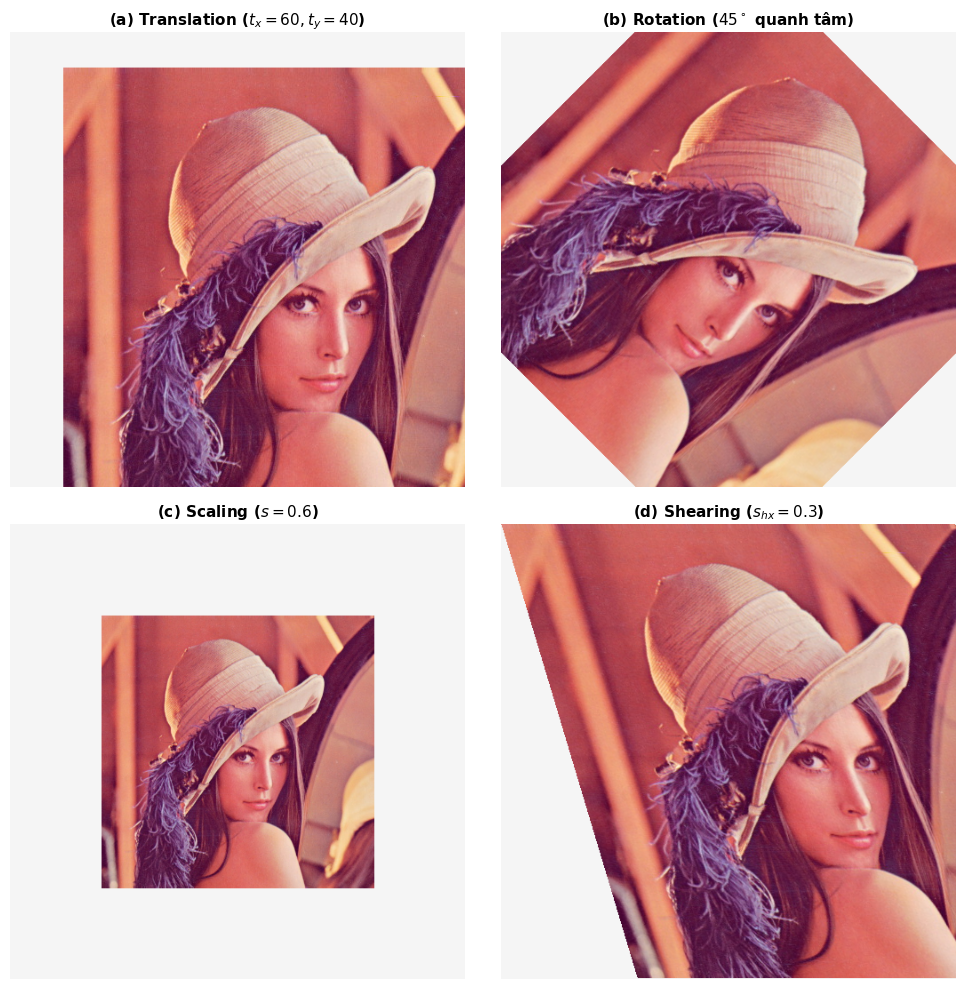

In [ ]:
# Đọc ảnh Lena
img_lena = cv2.imread('images/lena.jpg')
img_lena_rgb = cv2.cvtColor(img_lena, cv2.COLOR_BGR2RGB)
h, w = img_lena_rgb.shape[:2]
cx, cy = w / 2, h / 2

# a. Translation: vector (tx=60, ty=40)
M_trans = np.float32([[1, 0, 60],
                      [0, 1, 40]])
img_trans = warp_scratch(img_lena_rgb, M_trans, (h, w))

# b. Rotation: xoay 45 độ quanh tâm
theta = np.deg2rad(45)
cos_t, sin_t = np.cos(theta), np.sin(theta)
M_rot = np.float32([
    [cos_t, -sin_t, (1 - cos_t) * cx + sin_t * cy],
    [sin_t,  cos_t, -sin_t * cx + (1 - cos_t) * cy]
])
img_rot = warp_scratch(img_lena_rgb, M_rot, (h, w))

# c. Scaling: thu nhỏ 0.6x quanh tâm
s = 0.6
M_scale = np.float32([
    [s, 0, (1 - s) * cx],
    [0, s, (1 - s) * cy]
])
img_scale = warp_scratch(img_lena_rgb, M_scale, (h, w))

# d. Shearing: trượt tọa độ ngang sh_x = 0.3
M_shear = np.float32([
    [1, 0.3, 0],
    [0, 1,   0]
])
img_shear = warp_scratch(img_lena_rgb, M_shear, (h, w))

# Hiển thị trực quan dạng lưới 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(img_trans)
axes[0, 0].set_title("(a) Translation ($t_x=60, t_y=40$)", fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_rot)
axes[0, 1].set_title("(b) Rotation ($45^\circ$ quanh tâm)", fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_scale)
axes[1, 0].set_title("(c) Scaling ($s=0.6$)", fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_shear)
axes[1, 1].set_title("(d) Shearing ($s_{hx}=0.3$)", fontsize=11, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


### 5. So sánh trực quan Affine Transformation vs Projective Transformation trên bảng Sudoku

1. Ma trận Affine (2x3, 6 DoF) giải bằng np.linalg.solve:
 [[ 1.08530e+00  9.34000e-02 -8.84386e+01]
 [ 4.04000e-02  1.05000e+00 -9.43373e+01]]
-> Sai số tuyệt đối so với OpenCV: 0.0

2. Ma trận Projective (3x3, 8 DoF) giải bằng SVD (DLT):
 [[ 1.183400e+00  1.018000e-01 -9.643010e+01]
 [ 4.870000e-02  1.265300e+00 -1.136838e+02]
 [ 1.000000e-04  4.000000e-04  1.000000e+00]]
-> Sai số tuyệt đối so với OpenCV: 2.744826588241267e-10


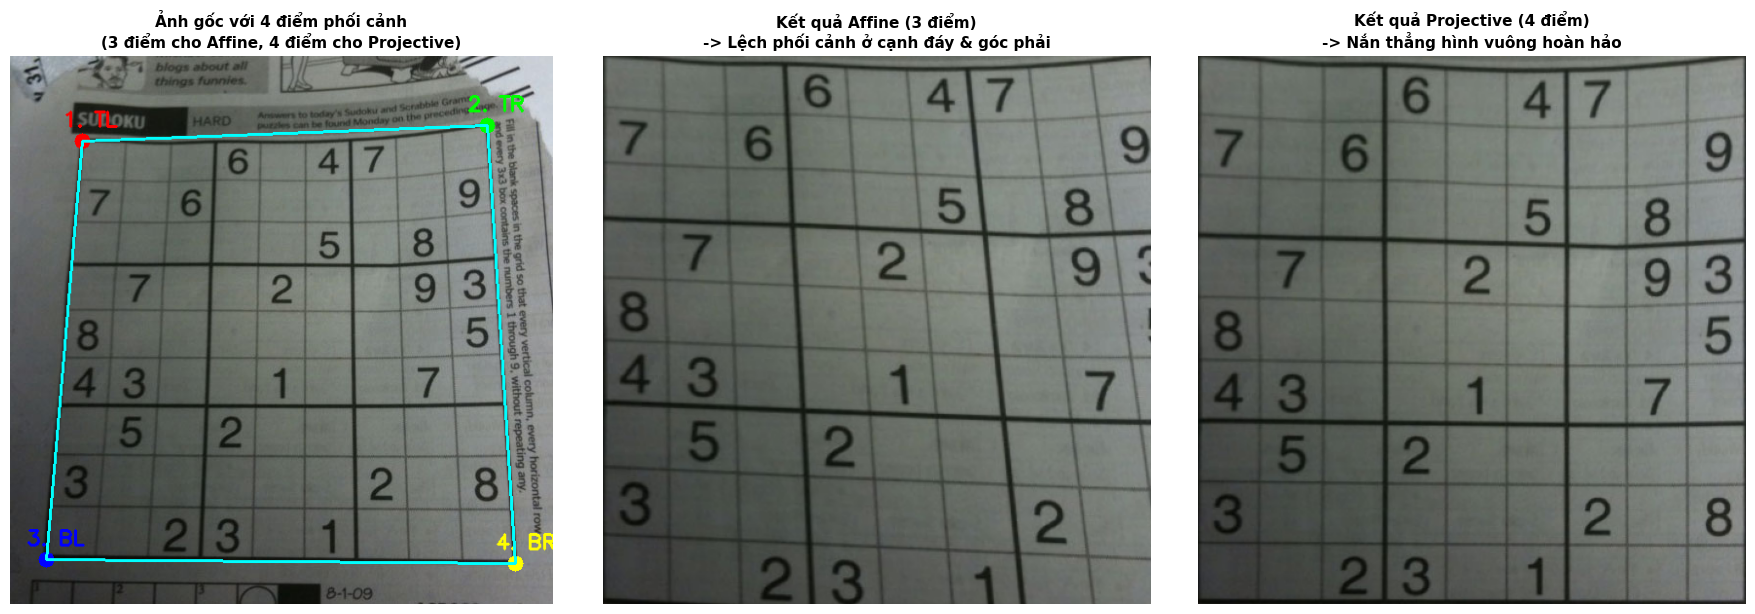

In [ ]:
# Đọc ảnh bảng Sudoku góc chụp nghiêng phối cảnh
img_sudoku = cv2.imread('images/sudoku.png')
img_sudoku_rgb = cv2.cvtColor(img_sudoku, cv2.COLOR_BGR2RGB)

# Tọa độ 4 góc của bảng Sudoku (Top-Left, Top-Right, Bottom-Left, Bottom-Right)
pts_src_4 = np.float32([
    [74, 87],    # TL
    [490, 71],   # TR
    [37, 517],   # BL
    [519, 521]   # BR
])

output_size = 450
pts_dst_4 = np.float32([
    [0, 0],
    [output_size, 0],
    [0, output_size],
    [output_size, output_size]
])

# --- 1. Tự tính ma trận Affine (3 cặp điểm đầu) & Warping ---
M_affine_custom = compute_affine_matrix(pts_src_4[:3], pts_dst_4[:3])
img_affine = warp_scratch(img_sudoku_rgb, M_affine_custom, (output_size, output_size))

# --- 2. Tự tính ma trận Projective / Homography DLT (4 cặp điểm) & Warping ---
M_proj_custom = compute_homography_dlt(pts_src_4, pts_dst_4)
img_projective = warp_scratch(img_sudoku_rgb, M_proj_custom, (output_size, output_size))

# Đối chiếu với ma trận tính bằng OpenCV
M_affine_cv = cv2.getAffineTransform(pts_src_4[:3], pts_dst_4[:3])
M_proj_cv = cv2.getPerspectiveTransform(pts_src_4, pts_dst_4)

print("1. Ma trận Affine (2x3, 6 DoF) giải bằng np.linalg.solve:\n", np.round(M_affine_custom, 4))
print("-> Sai số tuyệt đối so với OpenCV:", np.max(np.abs(M_affine_custom - M_affine_cv)))

print("\n2. Ma trận Projective (3x3, 8 DoF) giải bằng SVD (DLT):\n", np.round(M_proj_custom, 4))
print("-> Sai số tuyệt đối so với OpenCV:", np.max(np.abs(M_proj_custom - M_proj_cv)))

# Đánh dấu các điểm tương ứng trên ảnh gốc
img_markers = img_sudoku_rgb.copy()
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
labels = ['1. TL', '2. TR', '3. BL', '4. BR']

for i, pt in enumerate(pts_src_4):
    cv2.circle(img_markers, (int(pt[0]), int(pt[1])), 8, colors[i], -1)
    cv2.putText(img_markers, labels[i], (int(pt[0]) - 20, int(pt[1]) - 15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, colors[i], 2)

pts_poly = pts_src_4[[0, 1, 3, 2]].astype(np.int32).reshape((-1, 1, 2))
cv2.polylines(img_markers, [pts_poly], isClosed=True, color=(0, 255, 255), thickness=2)

# Hiển thị đối chiếu 3 ảnh
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_markers)
axes[0].set_title("Ảnh gốc với 4 điểm phối cảnh\n(3 điểm cho Affine, 4 điểm cho Projective)", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_affine)
axes[1].set_title("Kết quả Affine (3 điểm)\n-> Lệch phối cảnh ở cạnh đáy & góc phải", fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_projective)
axes[2].set_title("Kết quả Projective (4 điểm)\n-> Nắn thẳng hình vuông hoàn hảo", fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()
